# 01. Data Exploration (EDA)

This notebook checks the Leafsnap 30-species subset before any model training: whether every
image referenced by the official image list is actually readable, how balanced the 30 classes
are, how the dataset splits between `lab` (studio, controlled lighting, often with a ruler/color
card) and `field` (real-world phone photos), and what the image size distribution looks like. All
figures are regenerated from `data/metadata/images.csv`, which itself is built by
`src/data/build_metadata.py` from the official
`leafsnap-dataset-30subset-images.txt` list — the counts below should always match that file
(7,395 valid images, 30 classes) exactly.

In [1]:
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
from PIL import Image

NOTEBOOK_DIR = Path.cwd().resolve()
REPO_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

FIGURES_DIR = REPO_ROOT / "report/figures/data"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


def load_metadata(path: Path) -> list[dict[str, str]]:
    rows = []
    with path.open("r", encoding="utf-8") as f:
        headers = f.readline().strip().split(",")
        for line in f:
            parts = line.strip().split(",")
            if len(parts) < len(headers):
                continue
            rows.append(dict(zip(headers, parts)))
    return rows


samples = load_metadata(REPO_ROOT / "data/metadata/images.csv")
print(f"Loaded {len(samples)} metadata rows")

Loaded 7395 metadata rows


In [2]:
def inspect_images(samples):
    rows, missing = [], []
    for sample in samples:
        image_path = Path(sample["path"])
        if not image_path.exists():
            repo_candidate = REPO_ROOT / image_path
            if repo_candidate.exists():
                image_path = repo_candidate
            else:
                missing.append(str(sample["path"]))
                continue
        try:
            with Image.open(image_path) as image:
                width, height = image.size
                rows.append({
                    "path": str(image_path), "label": sample["label"], "source": sample["source"],
                    "width": width, "height": height, "mode": image.mode,
                    "aspect_ratio": round(width / height, 4) if height else 0,
                })
        except Exception as exc:
            missing.append(f"{image_path}: {exc}")
    return rows, missing


inspected, missing = inspect_images(samples)
print(f"Inspected {len(inspected)} readable images out of {len(samples)} metadata rows")
print(f"Missing or unreadable: {len(missing)}")

Inspected 7395 readable images out of 7395 metadata rows
Missing or unreadable: 0


**Data quality conclusion:** all 7,395 images referenced by the official image list opened
successfully (0 missing or unreadable) and every one decodes to RGB — there is no dead-file or
corrupt-image cleanup needed before training. This count matches
`leafsnap-dataset-30subset-images.txt` exactly, confirming `build_metadata.py` is no longer
silently dropping any official records (see `PART2_DATA.md` for the 156-image bug that used to
cause a 7,239 vs 7,395 mismatch here).

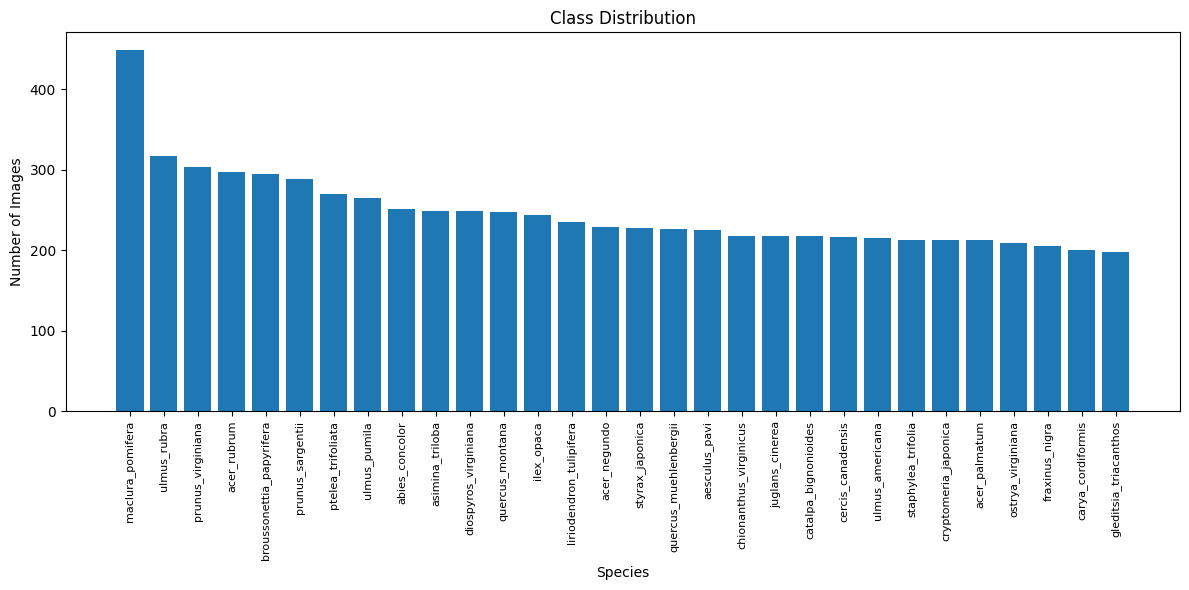

Smallest class: gleditsia_triacanthos (198 images)
Largest class: maclura_pomifera (448 images)
Imbalance ratio (max/min): 2.26x


In [3]:
label_counts = Counter(s["label"] for s in samples)
labels, values = zip(*sorted(label_counts.items(), key=lambda x: x[1], reverse=True))

plt.figure(figsize=(12, 6))
plt.bar(labels, values)
plt.xticks(rotation=90, fontsize=8)
plt.title("Class Distribution")
plt.xlabel("Species")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "class_distribution.png", dpi=200)
plt.show()

min_label, min_count = min(label_counts.items(), key=lambda x: x[1])
max_label, max_count = max(label_counts.items(), key=lambda x: x[1])
print(f"Smallest class: {min_label} ({min_count} images)")
print(f"Largest class: {max_label} ({max_count} images)")
print(f"Imbalance ratio (max/min): {max_count / min_count:.2f}x")

**Class distribution conclusion:** class sizes range from 198 (`gleditsia_triacanthos`) to 448
(`maclura_pomifera`) images — about a 2.3x imbalance, moderate rather than severe. It's not extreme
enough to require resampling, but it's large enough that macro-F1 (not just accuracy) should be
the primary metric, and per-class recall for the smallest classes is worth watching in the later
error analysis (member 5) — a model that quietly under-serves the ~200-image classes could still
post a good overall accuracy.

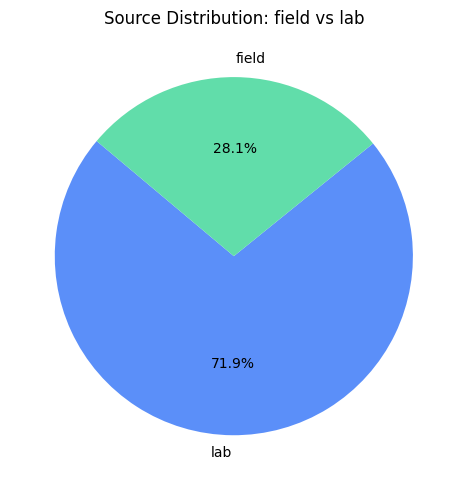

lab: 5320 images (71.9%)
field: 2075 images (28.1%)


In [4]:
source_counts = Counter(s["source"] for s in samples)

plt.figure(figsize=(5, 5))
plt.pie(source_counts.values(), labels=source_counts.keys(), autopct="%.1f%%", startangle=140,
        colors=["#5b8ff9", "#61dDAA"])
plt.title("Source Distribution: field vs lab")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "source_distribution.png", dpi=200)
plt.show()

total = sum(source_counts.values())
for source, count in source_counts.items():
    print(f"{source}: {count} images ({count / total:.1%})")

**Source distribution conclusion:** `lab` images make up 72.0% (5,320) of the dataset and
`field` only 28.0% (2,075). Since the project's stated goal is robustness to real-world lighting
conditions, this imbalance matters: a model trained on the full mixed set can get a misleadingly
high overall accuracy that is mostly explained by doing well on the easier, more plentiful lab
images, while still performing poorly on field images. This is exactly what the augmentation
ablation in `02_augmentation_ablation.ipynb` measures directly (lab accuracy vs field accuracy),
and it's why every model's evaluation in this project reports lab/field accuracy separately rather
than only an overall number.

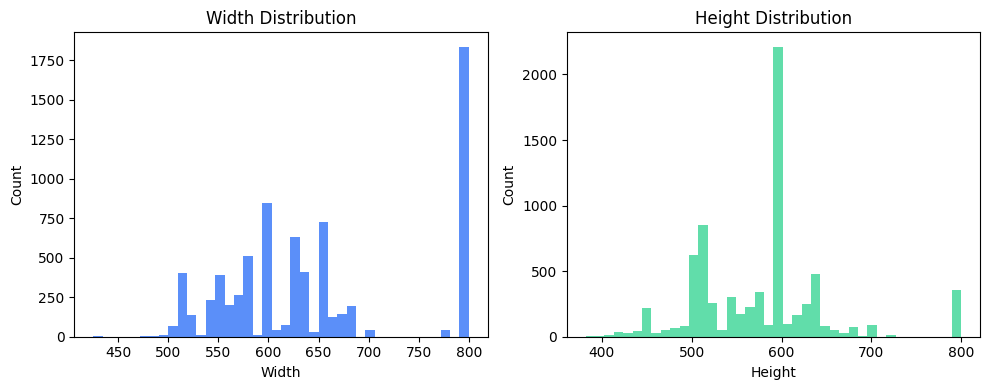

Width range: 425-800, mean 650
Height range: 382-800, mean 578


In [5]:
widths = [row["width"] for row in inspected]
heights = [row["height"] for row in inspected]

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(widths, bins=40, color="#5b8ff9")
plt.title("Width Distribution")
plt.xlabel("Width")
plt.ylabel("Count")
plt.subplot(1, 2, 2)
plt.hist(heights, bins=40, color="#61dDAA")
plt.title("Height Distribution")
plt.xlabel("Height")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "image_size_distribution.png", dpi=200)
plt.show()

print(f"Width range: {min(widths)}-{max(widths)}, mean {sum(widths)/len(widths):.0f}")
print(f"Height range: {min(heights)}-{max(heights)}, mean {sum(heights)/len(heights):.0f}")

**Image size conclusion:** widths range 425–800px and heights 382–800px (mean ≈650×578) — no
tiny thumbnails or huge outliers, and no image is smaller than the 224×224 input size every model
in this project uses, so the resize/pad pipeline in `src/data/transforms.py` never has to upscale
past native resolution. Aspect ratios are not fixed (leaves are photographed in varied
orientations), which is why `transforms.py` pads to a square before resizing instead of doing a
naive stretch — a straight resize would distort leaf shape, which is a meaningful classification
feature for this task.

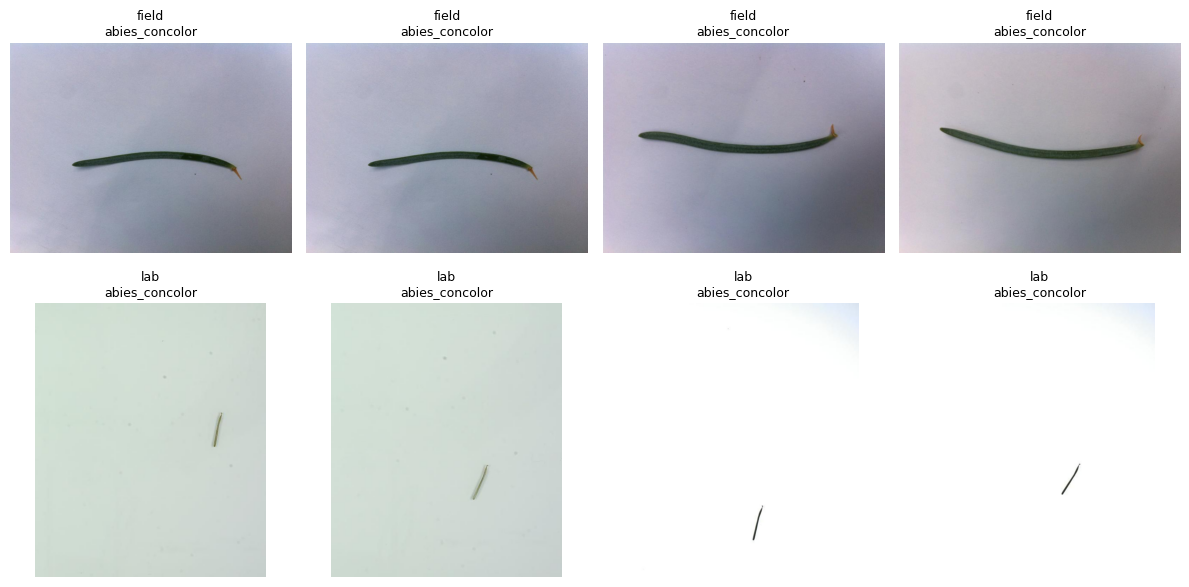

In [6]:
def plot_sample_pairs(samples, path, max_examples=8):
    fields = [s for s in samples if s["source"] == "field"]
    labs = [s for s in samples if s["source"] == "lab"]
    examples = []
    for subset in (fields, labs):
        examples.extend(sorted(subset, key=lambda s: s["label"])[: max_examples // 2])
    if not examples:
        return
    cols = 4
    rows = (len(examples) + cols - 1) // cols
    plt.figure(figsize=(cols * 3, rows * 3))
    for i, sample in enumerate(examples, start=1):
        with Image.open(sample["path"]) as image:
            image = image.convert("RGB")
            plt.subplot(rows, cols, i)
            plt.imshow(image)
            plt.axis("off")
            plt.title(f"{sample['source']}\n{sample['label']}", fontsize=9)
    plt.tight_layout()
    plt.savefig(path, dpi=200)
    plt.show()


plot_sample_pairs(inspected, FIGURES_DIR / "lab_vs_field_examples.png")

**Lab vs. field conclusion:** the `lab` examples are pressed leaves photographed flat against a
plain background with a color/scale reference card — high contrast, no occlusion, consistent
lighting. The `field` examples are leaves still on the plant or held up outdoors, with cluttered
natural backgrounds, variable lighting/shadow, partial occlusion by other leaves, and motion blur
in some shots. This visual gap is the concrete mechanism behind the lab/field accuracy gap
reported throughout this project (see the augmentation ablation and, later, the Grad-CAM analysis)
— it's not just a source label, it's a real domain shift the model has to bridge.

In [7]:
import json

quality_rows = [
    {k: row[k] for k in ("path", "label", "source", "width", "height", "mode", "aspect_ratio")}
    for row in inspected
]

quality_path = REPO_ROOT / "data/metadata/image_quality.csv"
with quality_path.open("w", encoding="utf-8", newline="") as f:
    fieldnames = ["path", "label", "source", "width", "height", "mode", "aspect_ratio"]
    f.write(",".join(fieldnames) + "\n")
    for row in quality_rows:
        f.write(",".join(str(row[field]) for field in fieldnames) + "\n")

summary = {
    "total_samples": len(samples),
    "readable_images": len(inspected),
    "missing_or_invalid": len(samples) - len(inspected),
    "field_images": source_counts.get("field", 0),
    "lab_images": source_counts.get("lab", 0),
    "class_count": len(label_counts),
}
summary_path = REPO_ROOT / "data/metadata/data_quality_summary.json"
summary_path.write_text(json.dumps(summary, indent=2), encoding="utf-8")
print(json.dumps(summary, indent=2))

{
  "total_samples": 7395,
  "readable_images": 7395,
  "missing_or_invalid": 0,
  "field_images": 2075,
  "lab_images": 5320,
  "class_count": 30
}
